In [1]:
from utlis import *
from config import *
from data import *
from model import *
from trainer import *
#from sae import *
from transformers import BertTokenizer
from torch.utils.data import DataLoader
from torch.optim import AdamW


/Users/jesanahammed/Math498-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from analysis import *

In [3]:
device = get_device()
datacon = DatasetConfig("/Users/jesanahammed/Desktop/IMDB/IMDB Dataset.csv", "csv", "review", "sentiment", 128)
modelcon = ModelConfig("bert-base-uncased", None)
tokenizer = BertTokenizer.from_pretrained(modelcon.model_name)

loader = DatasetLoader(datacon, tokenizer)
dataset, num_labels, label_map = loader.load()
print(num_labels)

modelcon.num_labels = num_labels

Map: 100%|██████████| 10000/10000 [00:01<00:00, 9328.35 examples/s]

2


In [4]:
trainingcon = TrainingConfig(32, 2, 2e-5, tokenizer)

In [5]:
train_loader = DataLoader(dataset["train"], batch_size=trainingcon.batch_size)
test_loader = DataLoader(dataset["test"], batch_size=trainingcon.batch_size)

In [6]:
model = BERTClassifier(modelcon, device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6850.91it/s]


In [7]:
optimizer = AdamW(model.model.parameters(), lr=trainingcon.lr)

In [8]:
trainer = Trainer(model.model, optimizer, device, datacon, trainingcon)

In [9]:
trainer.train(train_loader, trainingcon.epochs)

Epoch 0: Loss 0.3133
Epoch 1: Loss 0.1870


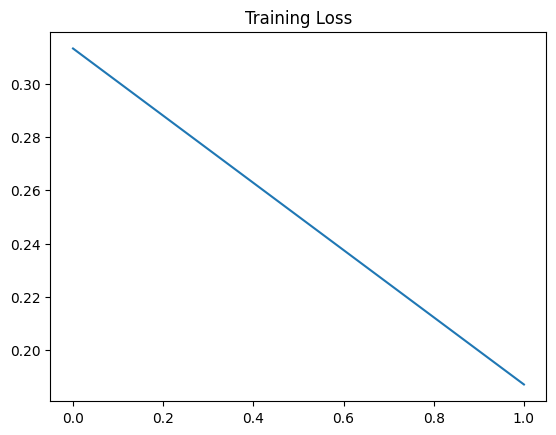

In [10]:
trainer.plot_loss()

In [11]:
trainer.evaluate(test_loader)

Confusion Matrix:
 [[4223  794]
 [ 344 4639]]


In [12]:
model.save("outputs/models/bert")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.49it/s]


In [13]:
model.load("outputs/models/bert")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 13962.26it/s]


In [14]:
dataset.set_format(type=None)  # IMPORTANT

N = 200

texts = dataset["test"]["review"][:N]
true_labels = torch.tensor(dataset["test"]["label"][:N])

print(texts)
print(true_labels)

Y = trainer.get_bert_predictions(texts)
print(Y)

["The 60s (1999) D: Mark Piznarski. Josh Hamilton, Julia Stiles, Jerry O'Connell, Jeremy Sisto, Jordana Brewster, Leonard Roberts, Bill Smitrovich, Annie Corley, Charles S. Dutton. NBC mini-series (later released to video/DVD as full length feature film) about the treacherous 1960s, as seen through the eyes of both a white family and a black family. The film's first half is driven by the excellent performance of Dutton as Reverend Willie Taylor and evenly spreads the storyline between the families. However, Dutton's character is killed halfway through and the black family is completely forgotten in a dull, incoherent, and downright awful 2nd half. RATING: 4 out of 10. Not rated (later rated PG-13 for video/DVD release).", "I just have to say that this was the third worst movie I have ever seen right after the attack of the murder tomato's 3 and starship troopers 2. It wasn't just dialogs or the paper walls or even the guns shots which just automagically disappeared with no holes in the

In [15]:
# saeconfig = gemmaConfig("google/gemma-2b", "gemma-scope-2b-pt-res-canonical", "layer_20/width_16k/canonical",
#                      2, texts, device
#                      )


In [12]:
# saeobj = GemmaScope(saeconfig)

In [3]:
# Z = saeobj.compute_sae_activation()

In [16]:
saeconfig = SAEConfig(
    model_name="gpt2",
    sae_release="gpt2-small-res-jb",
    sae_id="blocks.8.hook_resid_pre",
    layer=8,
    batch_size=4,
    texts=texts,
    device=device  # or "mps"
)

saeobj = ModelWithSAE(saeconfig)
Z = saeobj.compute_sae()
print(Z.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 320.84it/s]
/Users/jesanahammed/Math498-Project/.venv/lib/python3.12/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


torch.Size([200, 24576])


In [18]:
# import sae_lens

# print(dir(sae_lens))

['ActivationsStore', 'BatchTopKTrainingSAE', 'BatchTopKTrainingSAEConfig', 'CacheActivationsRunner', 'CacheActivationsRunnerConfig', 'GatedSAE', 'GatedSAEConfig', 'GatedTrainingSAE', 'GatedTrainingSAEConfig', 'HookedSAETransformer', 'JumpReLUSAE', 'JumpReLUSAEConfig', 'JumpReLUSkipTranscoder', 'JumpReLUSkipTranscoderConfig', 'JumpReLUTrainingSAE', 'JumpReLUTrainingSAEConfig', 'JumpReLUTranscoder', 'JumpReLUTranscoderConfig', 'LanguageModelSAERunnerConfig', 'LanguageModelSAETrainingRunner', 'LoggingConfig', 'MatchingPursuitSAE', 'MatchingPursuitSAEConfig', 'MatchingPursuitTrainingSAE', 'MatchingPursuitTrainingSAEConfig', 'MatryoshkaBatchTopKTrainingSAE', 'MatryoshkaBatchTopKTrainingSAEConfig', 'PretokenizeRunner', 'PretokenizeRunnerConfig', 'PretrainedSaeDiskLoader', 'PretrainedSaeHuggingfaceLoader', 'SAE', 'SAEConfig', 'SAETrainer', 'SAETrainingRunner', 'SAETransformerBridge', 'SkipTranscoder', 'SkipTranscoderConfig', 'StandardSAE', 'StandardSAEConfig', 'StandardTrainingSAE', 'Standard

In [28]:
# saeconfig = SAEConfig(
#     768, 5000, 1e-3, 32, 10, model, train_loader, 5000, device
# )

In [14]:
# import sys
# print(sys.executable)

/Users/jesanahammed/Math498-Project/.venv/bin/python


In [20]:
# from huggingface_hub import get_token

# token = get_token()
# print(token[:10] if token else None)

hf_OnNMfWc


In [9]:
# ts = trainsae(saeconfig)

In [24]:
# sae, H_norm, Y = ts.train_sae()

In [12]:
# Z = get_feature_activations(sae, H_norm, device)

In [17]:
def plot(Z):
    

    vals = Z.detach().cpu().numpy().flatten()

    plt.figure(figsize=(6,4))
    plt.hist(vals, bins=100)
    plt.title("Activation Distribution")
    plt.xlabel("Activation value")
    plt.ylabel("Frequency")
    plt.show()

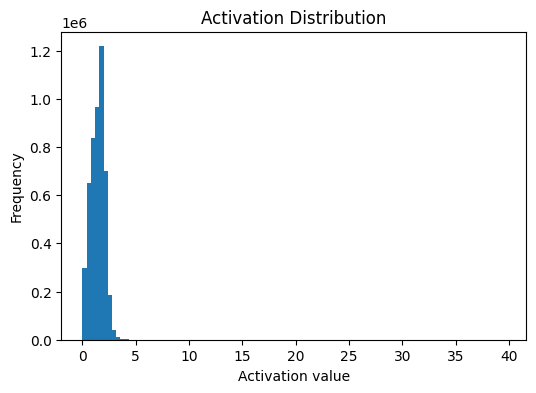

In [18]:
plot(Z)

In [19]:
importance = compute_feature_importance(Z, Y)
print(importance)
# top_features = get_top_features(importance, k=10)

# print("Top features:", top_features)

tensor([2.7029e-06, 9.5858e-07, 4.7534e-05,  ..., 2.9304e-06, 3.2448e-04,
        3.4350e-05])


In [20]:
p_values = compute_ttest(Z, Y)
reg_weights = compute_logistic_importance(Z, Y)

In [21]:
score = combine_scores(importance, p_values, reg_weights)

In [22]:
top_features = get_top_features(score, k=10)

print("Top features:", top_features)

Top features: tensor([18435, 20528, 18337,  6267, 18777, 15158, 19829, 13934,  8631,  3071])


In [23]:
dataset.set_format(type=None) 
for f in top_features:
    #print(dataset["train"].column_names)
    show_top_texts(f, Z, dataset, text_col=datacon.text_column)


===== Feature 18435 =====

I'm not usually into dark/psychological thriller type things. However, SEIZING ME is really an amazing piece of work. The story, acting, filming, psychological themes, erotic quality and spiritual understanding are all really quite complex and compelling. Rose plays the complexities and shifts of a psychologically disturbed woman really quite accurately. My partner was particularly impressed with the sophisticated way the power exchange issues were handled. It was so intense for us to watch that we found ourselves leaving it three quarters through to "get tea" and I felt compelled to have a shower. The story was gripping but we were clearly unable to handle all the energy in one straight shot. (It delves into the gritty and grimy side of people, but doesn't leave you there). I thought about the characters and deeper meanings for a long time. I would highly recommend this one. Still be prepared for an experience you might not be expecting.
---
As kids movie i